In [2]:
df = pd.read_csv("ecommerce_customer_data_large.csv")

In [3]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0.0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0.0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0.0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0.0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0.0


In [4]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0.0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0.0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0.0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0.0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0.0


In [5]:
df.shape

(49238, 13)

In [6]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,9261
Customer Name,0


In [7]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49238 entries, 0 to 49237
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Customer ID            49238 non-null  int64         
 1   Purchase Date          49238 non-null  datetime64[ns]
 2   Product Category       49238 non-null  object        
 3   Product Price          49238 non-null  int64         
 4   Quantity               49238 non-null  int64         
 5   Total Purchase Amount  49238 non-null  int64         
 6   Payment Method         49238 non-null  object        
 7   Customer Age           49238 non-null  int64         
 8   Returns                39977 non-null  float64       
 9   Customer Name          49238 non-null  object        
 10  Age                    49238 non-null  int64         
 11  Gender                 49237 non-null  object        
 12  Churn                  49237 non-null  float64       
dtypes

In [9]:
df.describe()

,Customer ID,Purchase Date,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,49238.000000,49238,49238.000000,49238.000000,49238.000000,49238.000000,39977.000000,49238.000000,49237.000000
mean,25003.215870,2021-11-06 21:52:07.755473408,254.425180,3.007819,2719.438320,43.770807,0.503339,43.770360,0.195788
min,6.000000,2020-01-01 01:44:13,10.000000,1.000000,109.000000,18.000000,0.000000,2.000000,0.000000
25%,12464.000000,2020-12-01 23:49:32,132.000000,2.000000,1479.000000,30.000000,0.000000,30.000000,0.000000
50%,25044.500000,2021-11-07 01:40:34.500000,255.000000,3.000000,2714.000000,44.000000,1.000000,44.000000,0.000000
75%,37252.750000,2022-10-13 11:06:35.750000128,376.000000,4.000000,3960.750000,57.000000,1.000000,57.000000,0.000000
max,50000.000000,2023-09-13 18:42:49,500.000000,5.000000,5349.000000,70.000000,1.000000,70.000000,1.000000
std,14447.442338,NaN,141.673237,1.412791,1438.384346,15.395932,0.499995,15.396825,0.396810


In [10]:
category_sales = df.groupby('Product Category')['Total Purchase Amount'].sum()

print(category_sales)

Product Category
Books          33092187
Clothing       33625063
Electronics    33690060
Home           33492394
Name: Total Purchase Amount, dtype: int64


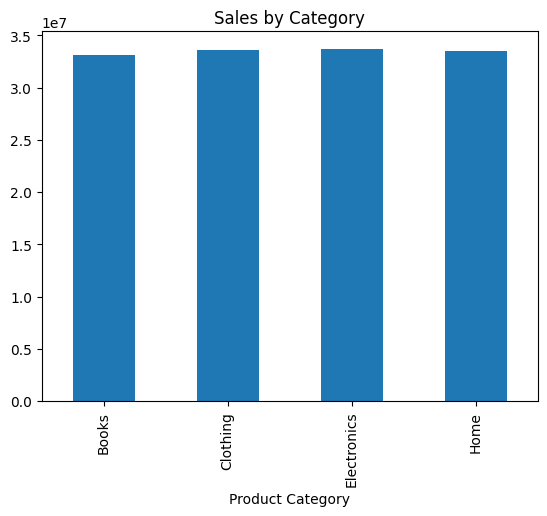

In [11]:
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

In [12]:
payment = df['Payment Method'].value_counts()

print(payment)

Payment Method
Credit Card    16566
Cash           16385
PayPal         16287
Name: count, dtype: int64


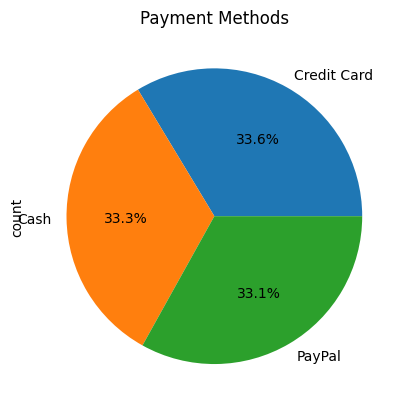

In [13]:
payment.plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Methods")
plt.show()

In [14]:
df['Churn'].value_counts()

,count
Churn,
0.0,39597
1.0,9640


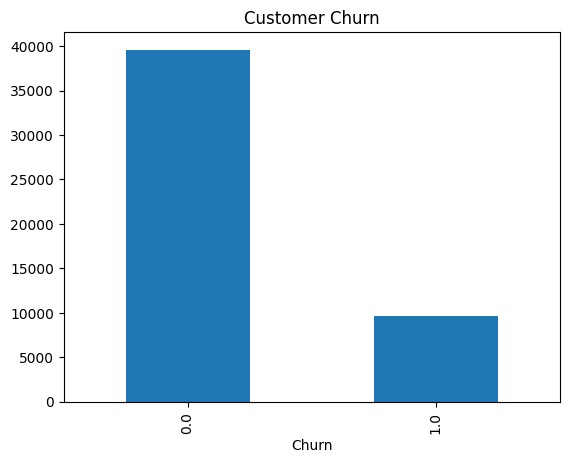

In [15]:
df['Churn'].value_counts().plot(kind='bar')
plt.title("Customer Churn")
plt.show()

In [16]:
latest_date = df['Purchase Date'].max()

In [17]:
rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (latest_date - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'
})

In [18]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [19]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
6,140,9,25428
7,141,8,17825
10,130,8,20672
14,263,5,14119
20,76,4,17443


In [20]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49238 entries, 0 to 49237
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Customer ID            49238 non-null  int64         
 1   Purchase Date          49238 non-null  datetime64[ns]
 2   Product Category       49238 non-null  object        
 3   Product Price          49238 non-null  int64         
 4   Quantity               49238 non-null  int64         
 5   Total Purchase Amount  49238 non-null  int64         
 6   Payment Method         49238 non-null  object        
 7   Customer Age           49238 non-null  int64         
 8   Returns                39977 non-null  float64       
 9   Customer Name          49238 non-null  object        
 10  Age                    49238 non-null  int64         
 11  Gender                 49237 non-null  object        
 12  Churn                  49237 non-null  float64       
dtypes

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,9261
Customer Name,0


In [21]:
df['Returns'] = df['Returns'].fillna(0)

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

df['Churn'] = df['Churn'].fillna(df['Churn'].mode()[0])

In [22]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,0
Customer Name,0


In [23]:
category_sales = df.groupby('Product Category')['Total Purchase Amount'].sum()

print(category_sales)

Product Category
Books          33092187
Clothing       33625063
Electronics    33690060
Home           33492394
Name: Total Purchase Amount, dtype: int64


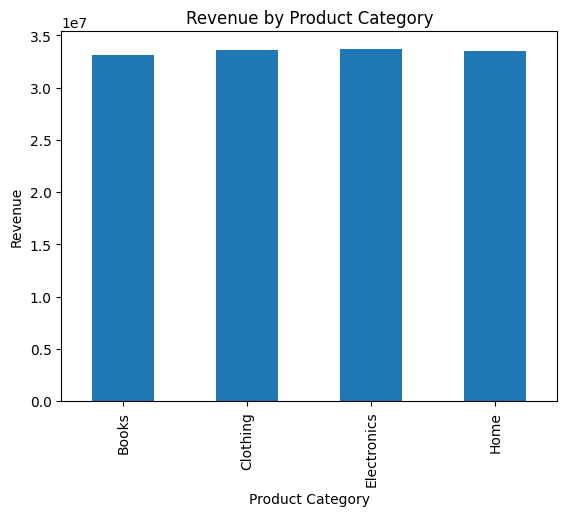

In [24]:
category_sales.plot(kind='bar')
plt.title("Revenue by Product Category")
plt.ylabel("Revenue")
plt.show()

In [25]:
payment = df['Payment Method'].value_counts()

print(payment)

Payment Method
Credit Card    16566
Cash           16385
PayPal         16287
Name: count, dtype: int64


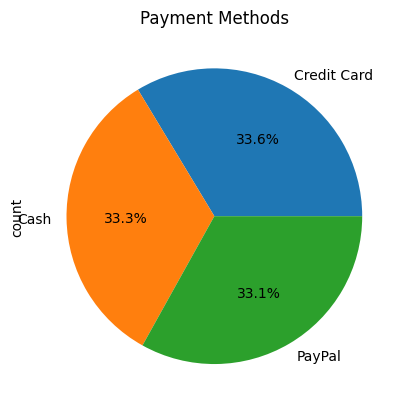

In [26]:
payment.plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Methods")
plt.show()

In [27]:
df['Churn'].value_counts()

,count
Churn,
0.0,39598
1.0,9640


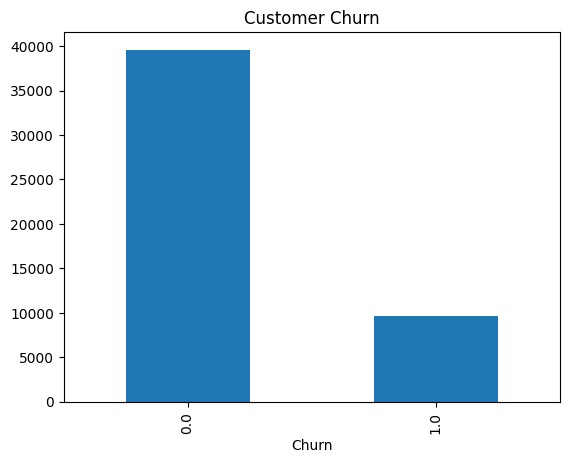

In [28]:
df['Churn'].value_counts().plot(kind='bar')
plt.title("Customer Churn")
plt.show()

In [29]:
age_sales = df.groupby('Age')['Total Purchase Amount'].sum()

age_sales.head()

,Total Purchase Amount
Age,
2,4102
18,2406873
19,2340531
20,2367247
21,2655072


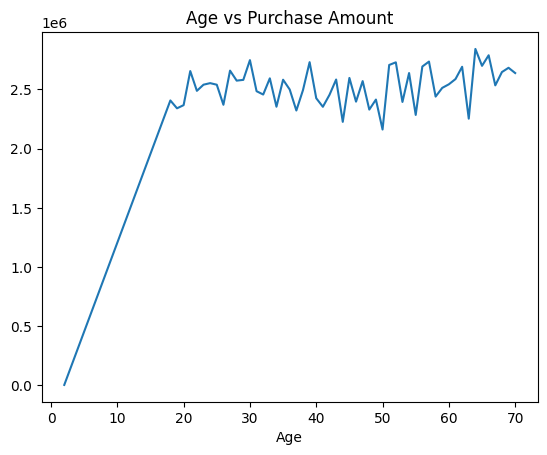

In [30]:
age_sales.plot(kind='line')
plt.title("Age vs Purchase Amount")
plt.show()

In [31]:
latest_date = df['Purchase Date'].max()

In [32]:
rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (latest_date - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'
})

In [33]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [34]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
6,140,9,25428
7,141,8,17825
10,130,8,20672
14,263,5,14119
20,76,4,17443


In [35]:
category_sales

,Total Purchase Amount
Product Category,
Books,33092187
Clothing,33625063
Electronics,33690060
Home,33492394


In [36]:
df['Churn'].value_counts()

,count
Churn,
0.0,39598
1.0,9640


In [37]:
payment

,count
Payment Method,
Credit Card,16566
Cash,16385
PayPal,16287


In [38]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
6,140,9,25428
7,141,8,17825
10,130,8,20672
14,263,5,14119
20,76,4,17443


In [39]:
rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (latest_date - x.max()).days,
    'Purchase Date': 'count',
    'Total Purchase Amount': 'sum'
})

In [40]:
rfm = df.groupby('Customer ID').agg({
    'Purchase Date': [
        lambda x: (latest_date - x.max()).days,
        'count'
    ],
    'Total Purchase Amount': 'sum'
})

In [41]:
rfm.columns = ['Recency','Frequency','Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
6,140,9,25428
7,141,8,17825
10,130,8,20672
14,263,5,14119
20,76,4,17443


In [43]:
rfm.describe()

,Recency,Frequency,Monetary
count,8341.000000,8341.000000,8341.00000
mean,219.106462,5.903129,16053.19554
std,209.870561,2.188802,6926.26979
min,0.000000,1.000000,292.00000
25%,66.000000,4.000000,11098.00000
50%,156.000000,6.000000,15312.00000
75%,304.000000,7.000000,20401.00000
max,1343.000000,17.000000,50496.00000


In [44]:
rfm['Segment'] = 'Regular'

rfm.loc[
    (rfm['Recency'] < 100) &
    (rfm['Frequency'] > 7) &
    (rfm['Monetary'] > 20000),
    'Segment'
] = 'Champions'

rfm.loc[
    (rfm['Recency'] < 200) &
    (rfm['Frequency'] > 5),
    'Segment'
] = 'Loyal Customers'

rfm.loc[
    (rfm['Recency'] > 300),
    'Segment'
] = 'At Risk'

rfm['Segment'].value_counts()

,count
Segment,
Loyal Customers,3130
Regular,3091
At Risk,2120


In [45]:
rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Segment,,,
At Risk,512.464151,4.833019,13089.155189
Loyal Customers,82.050479,7.646645,20757.709904
Regular,156.688774,4.871563,13322.246199


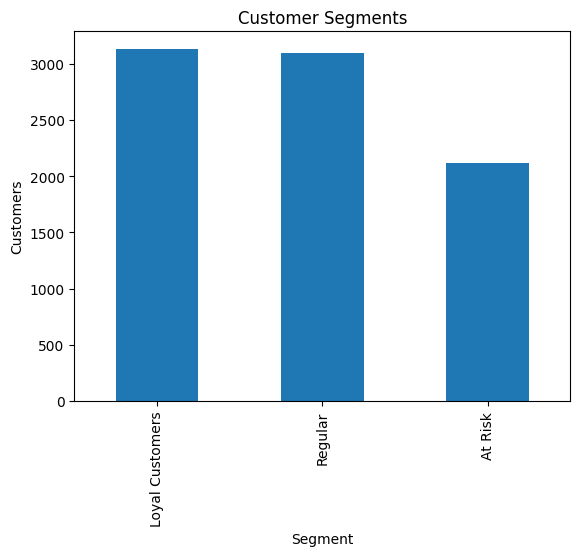

In [47]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(
    kind='bar'
)

plt.title("Customer Segments")
plt.ylabel("Customers")
plt.show()

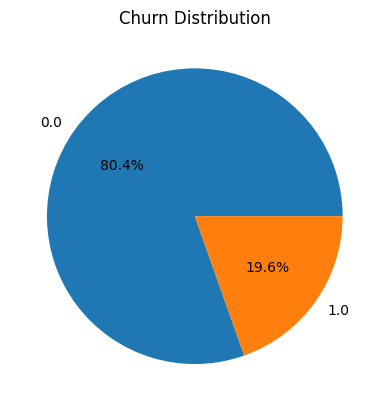

In [46]:
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Churn Distribution")
plt.ylabel("")
plt.show()

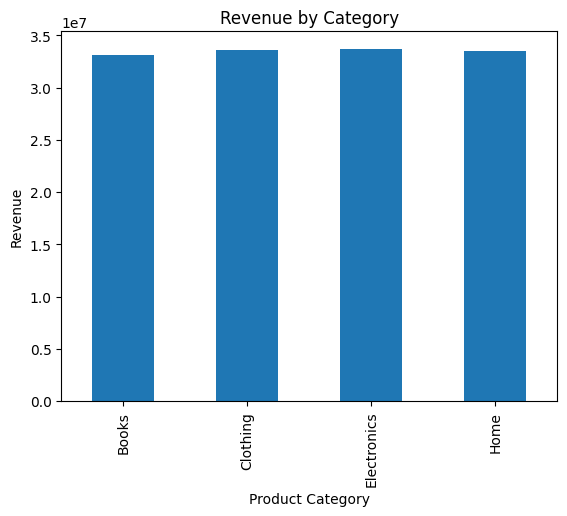

In [48]:
category_sales.plot(
    kind='bar'
)

plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.show()

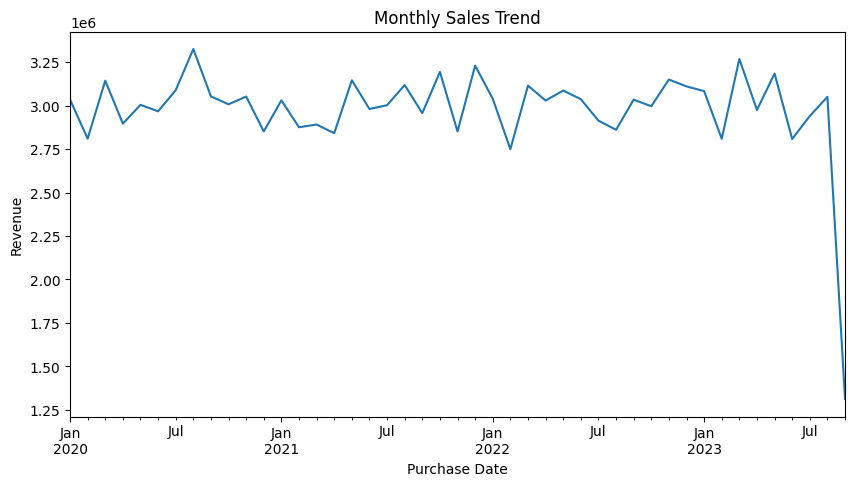

In [49]:
monthly_sales = df.groupby(
    df['Purchase Date'].dt.to_period('M')
)['Total Purchase Amount'].sum()

monthly_sales.plot(
    kind='line',
    figsize=(10,5)
)

plt.title("Monthly Sales Trend")
plt.ylabel("Revenue")
plt.show()

In [50]:
df.groupby('Churn')['Total Purchase Amount'].mean()

,Total Purchase Amount
Churn,
0.0,2721.721829
1.0,2710.058402


In [51]:
rfm['R_Score'] = pd.qcut(rfm['Recency'],
                         4,
                         labels=[4,3,2,1])

rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                         4,
                         labels=[1,2,3,4])

rfm['M_Score'] = pd.qcut(rfm['Monetary'],
                         4,
                         labels=[1,2,3,4])

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str)
    + rfm['F_Score'].astype(str)
    + rfm['M_Score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,Segment,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,,
6,140,9,25428,Loyal Customers,3,4,4,344
7,141,8,17825,Loyal Customers,3,4,3,343
10,130,8,20672,Loyal Customers,3,4,4,344
14,263,5,14119,Regular,2,2,2,222
20,76,4,17443,Regular,3,1,3,313


In [52]:
def segment_customer(row):
    if row['RFM_Score'] == '444':
        return 'Best Customers'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] >= 3:
        return 'Recent Customers'
    else:
        return 'At Risk'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm['Segment'].value_counts()

,count
Segment,
At Risk,4157
Loyal Customers,1975
Recent Customers,1679
Best Customers,530


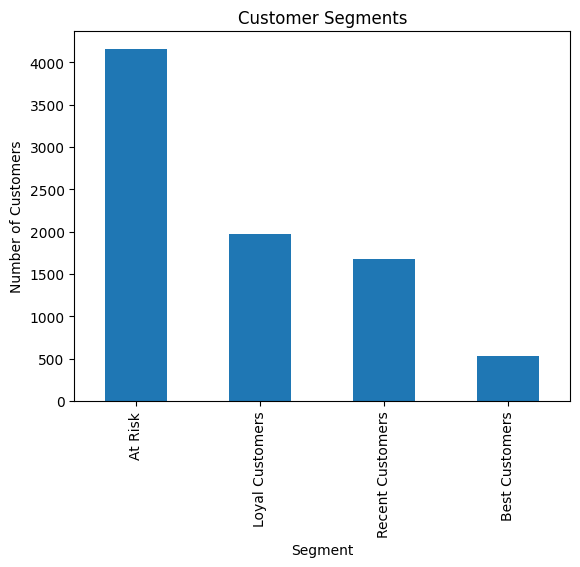

In [53]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(
    kind='bar'
)

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

In [54]:
rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Segment,,,
At Risk,369.669233,5.358191,14594.575174
Best Customers,30.247170,9.243396,26540.403774
Loyal Customers,76.412658,7.402532,19695.963544
Recent Customers,73.797499,4.434187,12069.156045


## Key Findings

1. Electronics generated the highest overall revenue, while Books generated the lowest revenue among all product categories.

2. Approximately 20% of customers were identified as churned, indicating a need for stronger retention strategies.

3. Customer payment preferences were evenly distributed across Credit Card, Cash, and PayPal, suggesting no strong dependency on a single payment method.

4. RFM segmentation revealed that the largest customer segment consists of At Risk customers (4,157 customers), indicating significant opportunities for re-engagement campaigns.

5. Best Customers demonstrated the highest purchase frequency and spending levels, making them ideal targets for loyalty and VIP programs.

## Recommendations

1. Launch targeted retention campaigns for At Risk customers using discounts and personalized offers.

2. Create loyalty rewards and exclusive benefits for Best Customers and Loyal Customers.

3. Increase promotional focus on Electronics products to maximize revenue growth.

4. Develop personalized marketing campaigns for Recent Customers to encourage repeat purchases.

5. Monitor churn trends and customer engagement metrics regularly to reduce future customer attrition.
